# Pairs trading with transaction costs

What is pairs trading? 

[Pairs trading](https://www.investopedia.com/terms/p/pairstrade.asp) is a market neutral trading strategy—it seeks to avoid some form of market risk entirely, typically by hedging—that involves taking simultaneously a long position with a short one in two highly correlated stocks or assets, this is crucial for the strategy, but finding and maintaining two assets that have a high correlation can be challenging.

> The strategy monitors performance of two historically correlated securities. When the correlation between the two securities temporarily weakens, i.e. one stock moves up while the other moves down, the pairs trade would be to short the outperforming stock and to long the underperforming one, betting that the "spread" between the two would eventually converge. [1]

The divergence within a pair can be caused by temporary supply/demand changes, large buy/sell orders for one security, reaction for important news about one of the companies, and so on.

> The reason for the deviated stock to come back to original value is itself an assumption. It is assumed that the pair will have similar business performance as in the past during the holding period of the stock.

**Potential drawbacks of the strategy:**

- The divergence between the prices of the securities can be a rational response to news related to one of the securities, invalidating the reversion to the mean assumption.
- Scarcity of opportunities
- Compete with HFT funds

Depending on the market sector, there exists multiple reasons for which two historically correlated securities can have differences on it's stock prices, e.g., company A's management could be extremely efficient while company B's management could be not efficient, this can cause stock A to rise and stock B to fall, and in this case it is not certain that stock B could go back to its mean since it's a management efficiency issue, hence shorting A and buying B would result in a potential loss. 

**Characteristics** 

- Pairs trading is a mean reverting strategy, betting that the prices will eventually return to historical trends, i.e., overperforming stock will do down to its historical mean and underperforming stock will go up to its historical mean

- Pairs trade can hedge sector and market risks, e.g., in case of a market crash, and the two positions going down with it, the trade would result in a gain on the short position and a loss on the long position, leaving a net profit close to breakeven.

**Potentially correlated pairs:**

- Coca Cola and Pepsi
- Walmart and Target
- Dell and HP
- Ford and General Motors

According to Skiena, highly-correlated pairs often (but not always) come from the same sector because they face similar systematic risks.

**Example:** 

> Pepsi (PEP) and Coca-Cola (KO) are different companies that create a similar product, soda pop. Historically, the two companies have shared similar dips and highs, depending on the soda pop market. If the price of Coca-Cola were to go up a significant amount while Pepsi stayed the same, a pairs trader would buy Pepsi stock and sell Coca-Cola stock, assuming that the two companies would later return to their historical balance point. If the price of Pepsi rose to close that gap in price, the trader would make money on the Pepsi stock, while if the price of Coca-Cola fell, they would make money on having shorted the Coca-Cola stock. [2]

## References
<a id="1">[1]</a> 
Skiena, S. 
[Lecture on pairs trading](https://www3.cs.stonybrook.edu/~skiena/691/lectures/lecture23.pdf)

<a id="2">[2]</a> 
Wikipedia. [Pair trading](https://en.wikipedia.org/wiki/Pairs_trade)




In [1]:
import torch
import torch.nn as nn
import numpy as np
from torch.autograd import grad
import torch.optim as optim
import math

torch.set_default_dtype(torch.float64)

# Model parameters
param = {
    # Initial condition
    'p0': 1,
    "mu": 0.2,
    "sigma": 0.4,
    "theta": 0.1,
    "kappa": 1.0,
    "nu": 0.15,
    "rho": 0.5,
    "r": 0.01,
    "gamma": 5.0,
    # Transaction cost params
    "ap": 1.0005,  # ap = 1 + zeta_p
    "bp": 0.9995,  # bp = 1 - eta_p
    "aq": 1.0005,  # aq = 1 + zeta_q
    "bq": 0.9995,  # bq = 1 - eta_q
    # Domain
    "T": 1.0
}

# A_minus and A_plus
def A_plus(p, x, p_dict=param):
    # A+ = (b_p - a_q * exp(x)) * p
    return (p_dict["bp"] - p_dict["aq"] * torch.exp(x)) * p

def A_minus(p, x, p_dict=param):
    # A- = (a_p - b_q * exp(x)) * p
    return (p_dict["ap"] - p_dict["bq"] * torch.exp(x)) * p

# Terminal payoff, i.e., liquidated value of the portfolio
# J(p(T), x(T), y(T)) = A+ * y 1{y>=0} + A- * y 1{y<0}
def terminal_J(p, x, y):
    if y >= 0:
        return A_plus(p, x) * y
    else:
        return A_minus(p, x) * y

# Neural network for H(t, p, x, y)
class Net(nn.Module):
    def __init__(self, in_dim, hidden=[64, 64, 64]):
        super(Net, self).__init__()
        layers = [nn.Linear(in_dim, hidden[0]), nn.Tanh()]
        for i in range(len(hidden) - 1):
            layers += [nn.Linear(hidden[i], hidden[i+1]), nn.Tanh()]
        layers += [nn.Linear(hidden[-1], 1)]
        self.net = nn.Sequential(*layers)

    def forward(self, *args):
        inputs = torch.cat([var.unsqueeze(1) if var.ndim == 1 else var for var in args], dim=1)
        return self.net(inputs).squeeze()
        
# Networks: u = log(H), Y_b, Y_s
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
net_u = Net(4).to(device)
net_yb = Net(3).to(device)
net_ys = Net(3).to(device)
params = list(net_u.parameters()) + list(net_yb.parameters()) + list(net_ys.parameters())
optimizer = torch.optim.Adam(params, lr=0.001)

# Domain bounds
t_min, t_max = 0.0, param['T']
p_min, p_max = 0.3, 4.0
x_min, x_max = -0.5, 0.5
y_min, y_max = -5.0, 5

# Sample function for t, p, x
def sample_tpx(batch_size):
    t = torch.rand(batch_size, device=device) * (t_max - t_min) + t_min
    p = torch.rand(batch_size, device=device) * (p_max - p_min) + p_min
    x = torch.rand(batch_size, device=device) * (x_max - x_min) + x_min
    t.requires_grad = True
    p.requires_grad = True
    x.requires_grad = True
    return t, p, x

# PDE residual for u (transformed L_{2,o} H = 0)
def pde_residual(u, t, p, x, p_dict=param):
    du_t = torch.autograd.grad(u.sum(), t, create_graph=True)[0]
    du_p = torch.autograd.grad(u.sum(), p, create_graph=True)[0]
    du_x = torch.autograd.grad(u.sum(), x, create_graph=True)[0]
    du_pp = torch.autograd.grad(du_p.sum(), p, create_graph=True)[0]
    du_xx = torch.autograd.grad(du_x.sum(), x, create_graph=True)[0]
    du_px = torch.autograd.grad(du_p.sum(), x, create_graph=True)[0]
    mu_x = p_dict['kappa'] * (p_dict['theta'] - x)
    mu_p = p_dict['mu'] * p
    sigma_xx = p_dict['nu'] ** 2
    sigma_xp = p_dict['rho'] * p_dict['nu'] * p_dict['sigma'] * p
    sigma_pp = (p_dict['sigma'] * p) ** 2
    res = (
        du_t + mu_x * du_x + mu_p * du_p +
        0.5 * sigma_xx * (du_xx + du_x ** 2) +
        sigma_xp * (du_px + du_p * du_x) +
        0.5 * sigma_pp * (du_pp + du_p ** 2)
    )
    return res

# Loss function
def loss_fn(batch_size=2000, delta_out=5.0):
    # Sample t, p, x
    t, p, x = sample_tpx(batch_size)
    yb = net_yb(t, p, x)
    ys = net_ys(t, p, x)
    loss_order = torch.mean(torch.relu(yb - ys) ** 2) * 10.0  # Stronger enforcement

    # Interior (NT region): sample y between yb and ys (if yb < ys)
    mask_valid = yb < ys
    n_valid = mask_valid.sum()
    if n_valid > 0:
        t_int, p_int, x_int, yb_int, ys_int = [var[mask_valid] for var in (t, p, x, yb, ys)]
        xi = torch.rand(n_valid, device=device)
        y_int = yb_int + xi * (ys_int - yb_int)
        y_int.requires_grad = True
        u_int = net_u(t_int, p_int, x_int, y_int)
        res = pde_residual(u_int, t_int, p_int, x_int, y_int)
        loss_nt = torch.mean(res ** 2)
    else:
        loss_nt = torch.tensor(0.0, device=device)

    # Buy region: y < yb
    y_buy = yb - torch.rand(batch_size, device=device) * delta_out
    y_buy = torch.clamp(y_buy, y_min, y_max)
    y_buy.requires_grad = True
    u_buy = net_u(t, p, x, y_buy)
    u_b = net_u(t, p, x, yb)
    exp_rt = torch.exp(param['r'] * (param['T'] - t))
    A_m = A_minus(p, x)
    target_buy = - param['gamma'] * exp_rt * A_m * (y_buy - yb) + u_b
    loss_buy = torch.mean((u_buy - target_buy) ** 2)

    # Sell region: y > ys
    y_sell = ys + torch.rand(batch_size, device=device) * delta_out
    y_sell = torch.clamp(y_sell, y_min, y_max)
    y_sell.requires_grad = True
    u_sell = net_u(t, p, x, y_sell)
    u_s = net_u(t, p, x, ys)
    A_p = A_plus(p, x)
    target_sell = - param['gamma'] * exp_rt * A_p * (y_sell - ys) + u_s
    loss_sell = torch.mean((u_sell - target_sell) ** 2)

    # Boundary conditions (separate samples for stability)
    t_b, p_b, x_b = sample_tpx(batch_size // 2)
    y_b = net_yb(t_b, p_b, x_b)
    u_yb = net_u(t_b, p_b, x_b, y_b)
    du_yb = torch.autograd.grad(u_yb.sum(), y_b, create_graph=True)[0]
    exp_rt_b = torch.exp(param['r'] * (param['T'] - t_b))
    A_m_b = A_minus(p_b, x_b)
    cond_b = du_yb + param['gamma'] * exp_rt_b * A_m_b
    loss_b = torch.mean(cond_b ** 2)

    t_s, p_s, x_s = sample_tpx(batch_size // 2)
    y_s = net_ys(t_s, p_s, x_s)
    u_ys = net_u(t_s, p_s, x_s, y_s)
    du_ys = torch.autograd.grad(u_ys.sum(), y_s, create_graph=True)[0]
    exp_rt_s = torch.exp(param['r'] * (param['T'] - t_s))
    A_p_s = A_plus(p_s, x_s)
    cond_s = du_ys + param['gamma'] * exp_rt_s * A_p_s
    loss_s = torch.mean(cond_s ** 2)

    # Terminal condition
    t_term = torch.full((batch_size,), param['T'], device=device)
    p_term = torch.rand(batch_size, device=device) * (p_max - p_min) + p_min
    x_term = torch.rand(batch_size, device=device) * (x_max - x_min) + x_min
    y_term = torch.rand(batch_size, device=device) * (y_max - y_min) + y_min
    u_term = net_u(t_term, p_term, x_term, y_term)
    target_term = - param['gamma'] * terminal_J(p_term, x_term, y_term)
    loss_term = torch.mean((u_term - target_term) ** 2)

    return loss_nt + loss_buy + loss_sell + loss_b + loss_s + loss_term + loss_order

# Training
for epoch in range(10000):
    optimizer.zero_grad()
    loss = loss_fn()
    if torch.isnan(loss) or torch.isinf(loss):
        print(f"Epoch {epoch}, NaN/Inf detected - skipping update")
        continue
    loss.backward()
    optimizer.step()
    if epoch % 100 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.6f}")

RuntimeError: you can only change requires_grad flags of leaf variables.

In [11]:
torch.rand(1000) * 1

tensor([5.3897e-01, 9.9915e-01, 4.3079e-01, 5.4432e-04, 7.1118e-01, 7.0896e-01,
        6.7426e-01, 8.4480e-01, 5.3236e-01, 5.3448e-01, 4.4488e-01, 6.3426e-01,
        4.0973e-01, 4.8942e-01, 1.9703e-01, 9.9845e-01, 3.0075e-01, 4.6255e-01,
        2.9675e-01, 1.8673e-01, 4.1362e-01, 8.7316e-01, 6.1304e-01, 9.0897e-01,
        6.2557e-01, 9.4969e-01, 9.0947e-01, 3.0014e-01, 6.9372e-02, 5.6318e-01,
        1.3351e-01, 5.0444e-01, 4.4198e-01, 9.1119e-01, 5.4486e-01, 6.8334e-02,
        1.9518e-01, 6.6682e-01, 8.0758e-01, 6.9290e-01, 5.0588e-01, 5.6253e-01,
        2.2974e-01, 5.2851e-02, 1.5766e-01, 2.5206e-01, 6.8815e-01, 8.1261e-02,
        3.7141e-01, 1.3390e-02, 4.0810e-01, 5.2384e-01, 9.8367e-02, 1.1642e-01,
        9.5114e-01, 4.0071e-02, 7.8183e-01, 5.5778e-01, 7.7286e-01, 8.8386e-02,
        5.7346e-01, 1.8310e-01, 8.3152e-01, 6.3345e-01, 3.5737e-01, 5.4524e-02,
        2.2303e-01, 6.6994e-01, 5.7862e-02, 4.8317e-01, 5.5546e-01, 5.7555e-01,
        7.3363e-01, 8.5406e-01, 7.2592e-

In [ ]:
# Neural networks for boundaries Y_b and Y_s (t, p, x)
class Boundary_NN(nn.Module):
    def __init__(self):
        super(Boundary_NN, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(3, 32),
            nn.Tanh(),
            nn.Linear(32, 32),
            nn.Tanh(),
            nn.Linear(32, 1)
        )

    def forward(self, t, p, x):
        input = torch.cat([t, p, x], dim=1)
        return self.net(input)
    
# Operator L2o (PDE in no-transaction region)
def L2o(H, t, p, x, y, p_dict=param):
    # First derivatives
    H_t = torch.autograd.grad(H, t, grad_outputs=torch.ones_like(H), create_graph=True, allow_unused=True, materialize_grads=True)[0]
    H_p = torch.autograd.grad(H, p, grad_outputs=torch.ones_like(H), create_graph=True, allow_unused=True, materialize_grads=True)[0]
    H_x = torch.autograd.grad(H, x, grad_outputs=torch.ones_like(H), create_graph=True, allow_unused=True, materialize_grads=True)[0]

    # Second derivatives
    H_pp = torch.autograd.grad(H_p, p, grad_outputs=torch.ones_like(H_p), create_graph=True, allow_unused=True, materialize_grads=True)[0]
    H_xx = torch.autograd.grad(H_x, x, grad_outputs=torch.ones_like(H_x), create_graph=True, allow_unused=True, materialize_grads=True)[0]
    H_px = torch.autograd.grad(H_p, x, grad_outputs=torch.ones_like(H_p), create_graph=True, allow_unused=True, materialize_grads=True)[0]

    # Auxiliary variables
    mu_x = p_dict['kappa'] * (p_dict['theta'] - x)
    mu_p = p_dict['mu'] * p
    sigma_xx = p_dict['nu'] ** 2
    sigma_xp = p_dict['rho'] * p_dict['nu'] * p_dict['sigma'] * p
    sigma_pp = (p_dict['sigma'] * p) ** 2
 
    # HJB operator LH

    LH = (
        H_t                          # H_t
        + mu_x * H_x                 # k(theta - x) * H_x
        + mu_p * H_p                 # mu_p * H_p
        + 0.5 * sigma_xx * H_xx      # 0.5 * sigma_xx * H_xx
        + sigma_xp * H_px            # sigma_xp * H_px
        + 0.5 * sigma_pp * H_pp      # 0.5 * sigma_pp * H_pp
    )

    return LH

# Operators L2b and L2s
def L2b(H, t, p, x, y, p_dict=param):
    H_y = torch.autograd.grad(H, y, grad_outputs=torch.ones_like(H), create_graph=True, allow_unused=True, materialize_grads=True)[0]

    # Auxiliary variable
    gamma_exp = p_dict['gamma'] * torch.exp(p_dict['r'] * (p_dict['T'] - t))

    L2bH = H_y + gamma_exp * A_minus(p, x) * H
    return L2bH

def L2s(H, t, p, x, y, p_dict=param):
    H_y = torch.autograd.grad(H, y, grad_outputs=torch.ones_like(H), create_graph=True, allow_unused=True, materialize_grads=True)[0]

    # Auxiliary variable
    gamma_exp = p_dict['gamma'] * torch.exp(p_dict['r'] * (p_dict['T'] - t))

    L2sH = H_y + gamma_exp * A_plus(p, x) * H
    return L2sH

# Explicit H in buy region (y <= Yb)
def H_buy(H_b, t, p, x, y, Yb, p_dict=param):
    # Auxiliar variable
    exp_r = torch.exp(p_dict['r'] * (p_dict['T'] - t))

    return torch.exp(-p_dict['gamma'] * exp_r * A_minus(p, x) * (y - Yb)) * H_b

# Explicit H in sell region (y >= Ys)
def H_sell(H_s, t, p, x, y, Ys, p_dict=param):
    # Auxiliar variable
    exp_r = torch.exp(p_dict['r'] * (p_dict['T'] - t))

    return torch.exp(-p_dict['gamma'] * exp_r * A_plus(p, x) * (y - Ys)) * H_s

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Training setup
h_nn = H_NN().to(device)
yb_nn = Boundary_NN().to(device)
ys_nn = Boundary_NN().to(device)
params = list(h_nn.parameters()) + list(yb_nn.parameters()) + list(ys_nn.parameters())
optimizer = optim.Adam(params, lr=0.001)

# Domain bounds
t_min, t_max = 0.0, param['T']
p_min, p_max = 0.3, 4.0
x_min, x_max = -0.5, 0.5
y_min, y_max = -20.0, 20.0

def sample_points(batch_size):
    # Create tensors of random points within the desired domain bounds
    t = torch.rand(batch_size, 1, device=device) * (t_max - t_min) + t_min
    p = torch.rand(batch_size, 1, device=device) * (p_max - p_min) + p_min
    x = torch.rand(batch_size, 1, device=device) * (x_max - x_min) + x_min
    y = torch.rand(batch_size, 1, device=device) * (y_max - y_min) + y_min
    t.requires_grad = True
    p.requires_grad = True
    x.requires_grad = True
    y.requires_grad = True
    return t, p, x, y

def loss_fn():
    # Generate some random points
    t, p, x, y = sample_points(10000)
    H = h_nn(t, p, x, y)
    Yb = yb_nn(t, p, x)
    Ys = ys_nn(t, p, x)

    # Interior loss (no-transaction region).
    mask_nt = (y >= Yb) & (y <= Ys)

    if mask_nt.any():
      loss_nt = torch.mean(L2o(H[mask_nt], t[mask_nt], p[mask_nt], x[mask_nt], y[mask_nt]) ** 2)
    else:
      loss_nt = torch.tensor(0.0, device=device)

    # Buy region loss
    mask_buy = y < Yb
    H_b = h_nn(t[mask_buy], p[mask_buy], x[mask_buy], Yb[mask_buy])
    loss_buy = torch.mean((H[mask_buy] - H_buy(H_b, t[mask_buy], p[mask_buy], x[mask_buy], y[mask_buy], Yb[mask_buy])) ** 2)

    # Sell region loss
    mask_sell = y > Ys
    H_s = h_nn(t[mask_sell], p[mask_sell], x[mask_sell], Ys[mask_sell])
    loss_sell = torch.mean((H[mask_sell] - H_sell(H_s, t[mask_sell], p[mask_sell], x[mask_sell], y[mask_sell], Ys[mask_sell])) ** 2)

    # Boundary conditions loss
    t_b, p_b, x_b, _ = sample_points(2000)  # Sample for boundaries
    y_b = yb_nn(t_b, p_b, x_b)
    H_yb = h_nn(t_b, p_b, x_b, y_b)
    loss_b = torch.mean(L2b(H_yb, t_b, p_b, x_b, y_b) ** 2)
    y_s = ys_nn(t_b, p_b, x_b)  # Reuse samples
    H_ys = h_nn(t_b, p_b, x_b, y_s)
    loss_s = torch.mean(L2s(H_ys, t_b, p_b, x_b, y_s) ** 2)

    # Terminal condition loss
    t_term = torch.ones(5000, 1, device=device) * param['T']
    p_term = torch.rand(5000, 1, device=device) * (p_max - p_min) + p_min
    x_term = torch.rand(5000, 1, device=device) * (x_max - x_min) + x_min
    y_term = torch.rand(5000, 1, device=device) * (y_max - y_min) + y_min
    H_term = h_nn(t_term, p_term, x_term, y_term)
    loss_term = torch.mean((H_term - torch.exp(-param['gamma'] * terminal_J(p_term, x_term, y_term))) ** 2)

    # Soft constraint for Yb < Ys
    loss_order = torch.mean(torch.relu(Yb - Ys) ** 2)

    return loss_nt + loss_buy + loss_sell + loss_b + loss_s + loss_term + 0.1 * loss_order

# Training loop
for epoch in range(10000):
    optimizer.zero_grad()
    loss = loss_fn()
    loss.backward()
    optimizer.step()
    if epoch % 100 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item()}")

In [21]:
import torch
import torch.nn as nn
import numpy as np
from torch.autograd import grad
import torch.optim as optim
import math

torch.set_default_dtype(torch.float64)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Model parameters
param = {
    # Initial condition
    'p0': 1,
    "mu": 0.2,
    "sigma": 0.4,
    "theta": 0.1,
    "kappa": 1.0,
    "nu": 0.15,
    "rho": 0.5,
    "r": 0.01,
    "gamma": 5.0,
    # Transaction cost params
    "ap": 1.0005,  # ap = 1 + zeta_p
    "bp": 0.9995,  # bp = 1 - eta_p
    "aq": 1.0005,  # aq = 1 + zeta_q
    "bq": 0.9995,  # bq = 1 - eta_q
    # Domain
    "T": 1.0
}

# A_minus and A_plus
def A_minus(p, x):
    # A- = (a_p - b_q * exp(x)) * p
    return (param["ap"] - param["bq"] * torch.exp(x)) * p

def A_plus(p, x):
    # A+ = (b_p - a_q * exp(x)) * p
    return (param["bp"] - param["aq"] * torch.exp(x)) * p

# Terminal payoff, i.e., liquidated value of the portfolio
# J(p(T), x(T), y(T)) = A+ * y 1{y>=0} + A- * y 1{y<0}
def terminal_J(p, x, y):
    return torch.where(y >= 0, A_plus(p, x) * y, A_minus(p, x) * y)

# Neural network for H(t, p, x, y)
class Net(nn.Module):
    def __init__(self, n_in, n_out=1, layers=[64, 64, 64]):
        super().__init__()
        seq = [nn.Linear(n_in, layers[0]), nn.Tanh()]
        for i in range(len(layers)-1):
            seq += [nn.Linear(layers[i], layers[i+1]), nn.Tanh()]
        seq.append(nn.Linear(layers[-1], n_out))
        self.net = nn.Sequential(*seq)
    def forward(self, *args):
        x = torch.cat([a if a.ndim > 1 else a.unsqueeze(1) for a in args], dim=1)
        return self.net(x).squeeze(-1)

net_u  = Net(4).to(device)          # u = log H(t,p,x,y)
net_yb = Net(3).to(device)          # buy boundary Y_b(t,p,x)
net_ys = Net(3).to(device)          # sell boundary Y_s(t,p,x)

optimizer = torch.optim.Adam(list(net_u.parameters()) +
                            list(net_yb.parameters()) +
                            list(net_ys.parameters()), lr=1e-3)

#scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10000, gamma=0.8)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=500, factor=0.5)

# Domain bounds
t_min, t_max = 0.0, param['T']
p_min, p_max = 0.3, 4.0
x_min, x_max = -0.5, 0.5
y_min, y_max = -15, 15

# Sample function for t, p, x
def sample_tpx(batch_size):
    t = torch.rand(batch_size, device=device) * (t_max - t_min) + t_min
    p = torch.rand(batch_size, device=device) * (p_max - p_min) + p_min
    x = torch.rand(batch_size, device=device) * (x_max - x_min) + x_min
    t.requires_grad = True
    p.requires_grad = True
    x.requires_grad = True
    return t, p, x

# PDE residual for u = log H (transformed L_{2,o} H = 0)
def pde_residual(u, t, p, x, y):
    grads = torch.autograd.grad(u, (t, p, x, y), 
                               grad_outputs=torch.ones_like(u),
                               create_graph=True, retain_graph=True)
    du_t, du_p, du_x = grads[0], grads[1], grads[2]

    # Second derivatives
    du_pp = torch.autograd.grad(du_p, p, torch.ones_like(du_p), create_graph=True)[0]
    du_xx = torch.autograd.grad(du_x, x, torch.ones_like(du_x), create_graph=True)[0]
    du_px = torch.autograd.grad(du_p, x, torch.ones_like(du_p), create_graph=True)[0]

    res = (du_t
            + param["kappa"]*(param["theta"] - x)*du_x
            + param["mu"]*p*du_p
            + 0.5*param["nu"]**2 * (du_xx + du_x**2)
            + param["rho"]*param["nu"]*param["sigma"]*p * (du_px + du_p*du_x)
            + 0.5*(param["sigma"]*p)**2 * (du_pp + du_p**2))
    return res

# Loss function
def compute_loss(n_batch=3000, delta_out=4.0):
    # Common points
    t, p, x = sample_tpx(n_batch)
    yb = net_yb(t, p, x)
    ys = net_ys(t, p, x)
    loss_order = 10.0 * torch.mean(torch.clamp(yb - ys, min=0.0)**2)

    # No-transaction region (interior)
    mask = yb < ys
    if mask.any():
        t_i, p_i, x_i, yb_i, ys_i = t[mask], p[mask], x[mask], yb[mask], ys[mask]
        # Fresh leaf variable for y
        xi = torch.rand_like(yb_i)
        y_i = yb_i + xi * (ys_i - yb_i)
        y_i.requires_grad_(True)                   
        u_i = net_u(t_i, p_i, x_i, y_i)
        loss_nt = torch.mean(pde_residual(u_i, t_i, p_i, x_i, y_i)**2)
    else:
        loss_nt = torch.tensor(0.0, device=device)

    # Buy region
    y_buy = yb - torch.rand_like(yb) * delta_out
    y_buy.requires_grad_(True)
    u_buy = net_u(t, p, x, y_buy)   # u(t,p,x,y)  where y = log H at a point inside buy region
    u_b   = net_u(t, p, x, yb)      # u(t,p,x,Y_b) = log H on the buy boundaryb
    target_buy = u_b - param["gamma"] * torch.exp(param["r"]*(param["T"]-t)) * A_minus(p, x) * (y_buy - yb)
    loss_buy = torch.mean((u_buy - target_buy)**2)

    # Sell region
    y_sell = ys + torch.rand_like(ys) * delta_out
    y_sell.requires_grad_(True)
    u_sell = net_u(t, p, x, y_sell)
    u_s   = net_u(t, p, x, ys)
    target_sell = u_s - param["gamma"] * torch.exp(param["r"]*(param["T"]-t)) * A_plus(p, x) * (y_sell - ys)
    loss_sell = torch.mean((u_sell - target_sell)**2)

    # Boundary conditions (smooth pasting)
    # buy boundary
    yb_b = net_yb(t, p, x)
    yb_b.requires_grad_(True)
    uy_b = torch.autograd.grad(net_u(t, p, x, yb_b), yb_b,
                              torch.ones_like(yb_b), create_graph=True)[0]
    loss_bc_buy = torch.mean((uy_b + param["gamma"] *
                             torch.exp(param["r"]*(param["T"]-t)) * A_minus(p, x))**2)

    # sell boundary
    ys_s = net_ys(t, p, x)
    ys_s.requires_grad_(True)
    uy_s = torch.autograd.grad(net_u(t, p, x, ys_s), ys_s,
                              torch.ones_like(ys_s), create_graph=True)[0]
    loss_bc_sell = torch.mean((uy_s + param["gamma"] *
                              torch.exp(param["r"]*(param["T"]-t)) * A_plus(p, x))**2)

    # Terminal condition 
    t_term = torch.full((n_batch,), param["T"], device=device)
    p_term, x_term, y_term = sample_tpx(n_batch)[1], sample_tpx(n_batch)[2], \
                             (torch.rand(n_batch, device=device) * (y_max - y_min) + y_min)
    u_term = net_u(t_term, p_term, x_term, y_term)
    loss_term = torch.mean((u_term + param["gamma"] * terminal_J(p_term, x_term, y_term))**2)

    total = (loss_nt + loss_buy + loss_sell +
             loss_bc_buy + loss_bc_sell + loss_term + loss_order)
    return total

# Training loop (now robust)

training_params = {'epochs': 30000,
                   'n_batch': 1000}
for epoch in range(training_params["epochs"]):
    optimizer.zero_grad()
    loss = compute_loss(n_batch=training_params["n_batch"])
    loss.backward()

    torch.nn.utils.clip_grad_norm_(net_u.parameters(), max_norm=1.0)
    torch.nn.utils.clip_grad_norm_(net_yb.parameters(), max_norm=1.0)
    torch.nn.utils.clip_grad_norm_(net_ys.parameters(), max_norm=1.0)

    optimizer.step()
    scheduler.step(loss)

    if epoch % 500 == 0:
        print(f"Epoch {epoch:5d}  loss = {loss.item():.3e}")

print("Training finished!")

Epoch     0  loss = 1.048e+03
Epoch   500  loss = 3.499e+02
Epoch  1000  loss = 2.893e+02
Epoch  1500  loss = 1.362e+02
Epoch  2000  loss = 1.428e+02
Epoch  2500  loss = 7.737e+01
Epoch  3000  loss = 3.003e+01
Epoch  3500  loss = 3.613e+01
Epoch  4000  loss = 2.058e+01
Epoch  4500  loss = 2.002e+01
Epoch  5000  loss = 9.429e+00
Epoch  5500  loss = 1.563e+01
Epoch  6000  loss = 2.342e+00
Epoch  6500  loss = 4.298e+00
Epoch  7000  loss = 3.243e+00
Epoch  7500  loss = 2.171e+00
Epoch  8000  loss = 1.113e-01
Epoch  8500  loss = 1.486e+00
Epoch  9000  loss = 7.962e-01
Epoch  9500  loss = 2.176e+00
Epoch 10000  loss = 6.850e-01
Epoch 10500  loss = 6.155e-01
Epoch 11000  loss = 6.073e-01
Epoch 11500  loss = 5.159e-01
Epoch 12000  loss = 5.720e-01
Epoch 12500  loss = 2.513e-01
Epoch 13000  loss = 4.612e-01
Epoch 13500  loss = 1.489e+00
Epoch 14000  loss = 6.365e-01
Epoch 14500  loss = 1.434e-01
Epoch 15000  loss = 2.737e-01
Epoch 15500  loss = 1.622e-01
Epoch 16000  loss = 4.115e-01
Epoch 1650

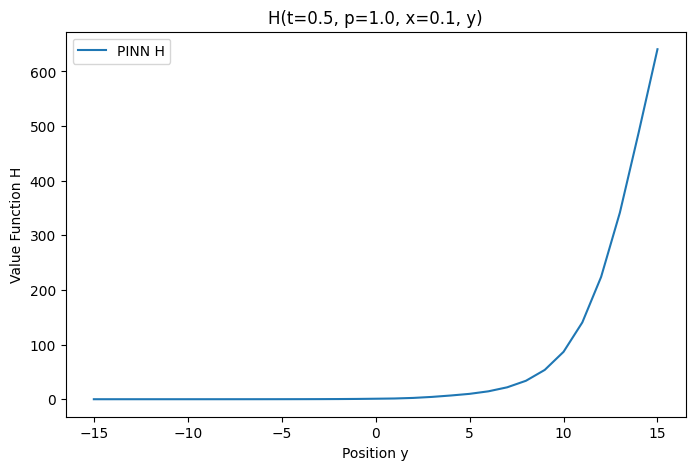

In [16]:
import numpy as np
import matplotlib.pyplot as plt
import torch

# Assume nets loaded, device set
net_u.eval()  # Set to evaluation mode

# Example grid (match DP: t=0 to 1, p~[0.7,2.5], x~[-0.3,0.4], y~[-15,15])
t_vals = np.linspace(0, 1, 301)
p_vals = np.exp(np.linspace(np.log(0.7), np.log(2.5), 51))  # DP uses exp grid
x_vals = np.linspace(-0.3, 0.4, 51)
y_vals = np.arange(-15, 16)

# Fix t=0.5, p=1.0, x=0.1; compute H vs y
t_fixed = torch.full((len(y_vals),), 0.5, device=device)
p_fixed = torch.full((len(y_vals),), 1.0, device=device)
x_fixed = torch.full((len(y_vals),), 0.1, device=device)
y_tensor = torch.tensor(y_vals, dtype=torch.float64, device=device)

u_vals = net_u(t_fixed, p_fixed, x_fixed, y_tensor)
H_vals = torch.exp(u_vals).cpu().detach().numpy()  # H = exp(u)

# Plot H vs y (similar to value function slices in notebook)
plt.figure(figsize=(8, 5))
plt.plot(y_vals, H_vals, label='PINN H')
plt.xlabel('Position y')
plt.ylabel('Value Function H')
plt.title('H(t=0.5, p=1.0, x=0.1, y)')
plt.legend()
plt.show()

In [17]:
H_vals

array([5.25842178e-04, 7.45514382e-04, 1.10587138e-03, 1.71359160e-03,
       2.76171231e-03, 4.59536848e-03, 7.81623393e-03, 1.34365964e-02,
       2.30957095e-02, 3.93741479e-02, 6.63146078e-02, 1.10420897e-01,
       1.83109554e-01, 3.08993644e-01, 5.25918180e-01, 9.03541502e-01,
       1.33757459e+00, 2.38568635e+00, 4.25170955e+00, 6.81248895e+00,
       9.83625289e+00, 1.44565668e+01, 2.18066926e+01, 3.37773238e+01,
       5.36476685e+01, 8.67218660e+01, 1.40584383e+02, 2.23827533e+02,
       3.41660000e+02, 4.88299154e+02, 6.40650617e+02])

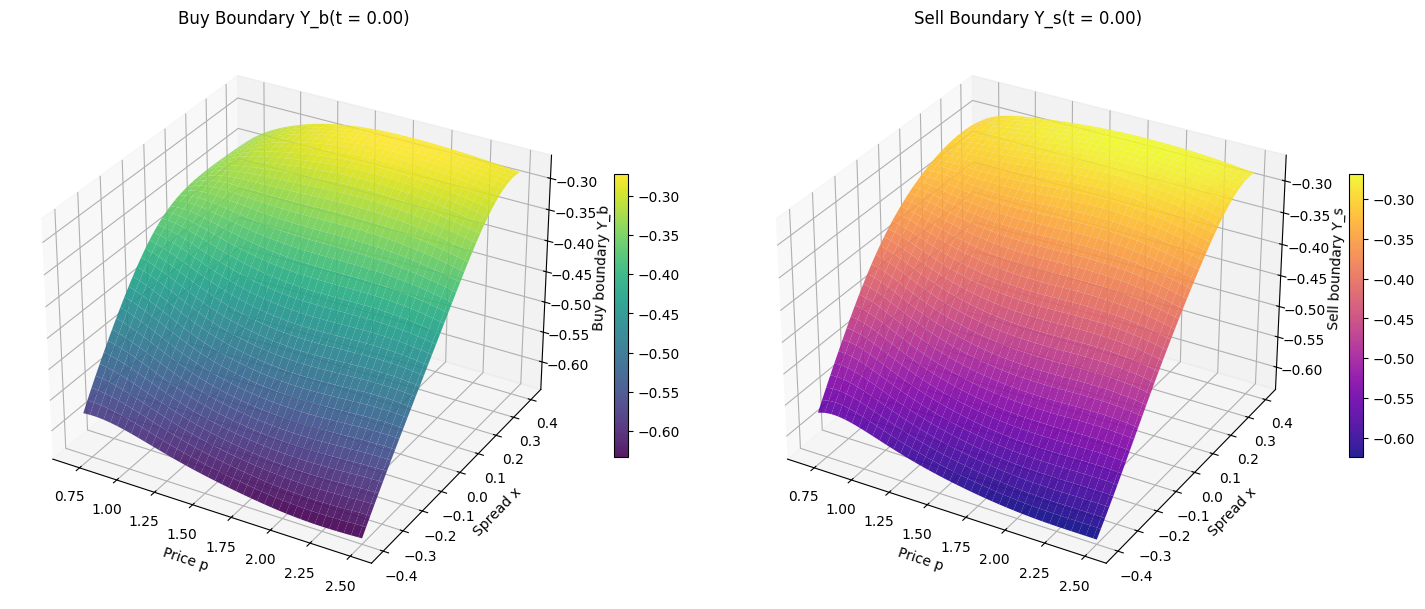

In [8]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Make sure models are in eval mode
net_yb.eval()
net_ys.eval()
net_u.eval()

# === 1. 3D surface plots of Y_b and Y_s at fixed time (like Fig.1 in the paper) ===
t_fixed = 0.0  # or 0.5, 0.9, etc.

# Create regular grid in (p, x) space
p_vec = np.linspace(0.7, 2.5, 80)
x_vec = np.linspace(-0.4, 0.4, 80)
P_grid, X_grid = np.meshgrid(p_vec, x_vec)

# Flatten for network input
P_flat = torch.tensor(P_grid.ravel(), dtype=torch.float64, device=device)
X_flat = torch.tensor(X_grid.ravel(), dtype=torch.float64, device=device)
T_flat = torch.full_like(P_flat, t_fixed)

# Forward pass
with torch.no_grad():
    Yb_flat = net_yb(T_flat, P_flat, X_flat)
    Ys_flat = net_ys(T_flat, P_flat, X_flat)

# Reshape back to 2D
Yb_grid = Yb_flat.cpu().numpy().reshape(P_grid.shape)
Ys_grid = Ys_flat.cpu().numpy().reshape(P_grid.shape)

# Plot
fig = plt.figure(figsize=(15, 6))

ax1 = fig.add_subplot(121, projection='3d')
surf1 = ax1.plot_surface(P_grid, X_grid, Yb_grid, cmap='viridis', alpha=0.9)
ax1.set_xlabel('Price p')
ax1.set_ylabel('Spread x')
ax1.set_zlabel('Buy boundary Y_b')
ax1.set_title(f'Buy Boundary Y_b(t = {t_fixed:.2f})')
fig.colorbar(surf1, ax=ax1, shrink=0.5)

ax2 = fig.add_subplot(122, projection='3d')
surf2 = ax2.plot_surface(P_grid, X_grid, Ys_grid, cmap='plasma', alpha=0.9)
ax2.set_xlabel('Price p')
ax2.set_ylabel('Spread x')
ax2.set_zlabel('Sell boundary Y_s')
ax2.set_title(f'Sell Boundary Y_s(t = {t_fixed:.2f})')
fig.colorbar(surf2, ax=ax2, shrink=0.5)

plt.tight_layout()
plt.show()

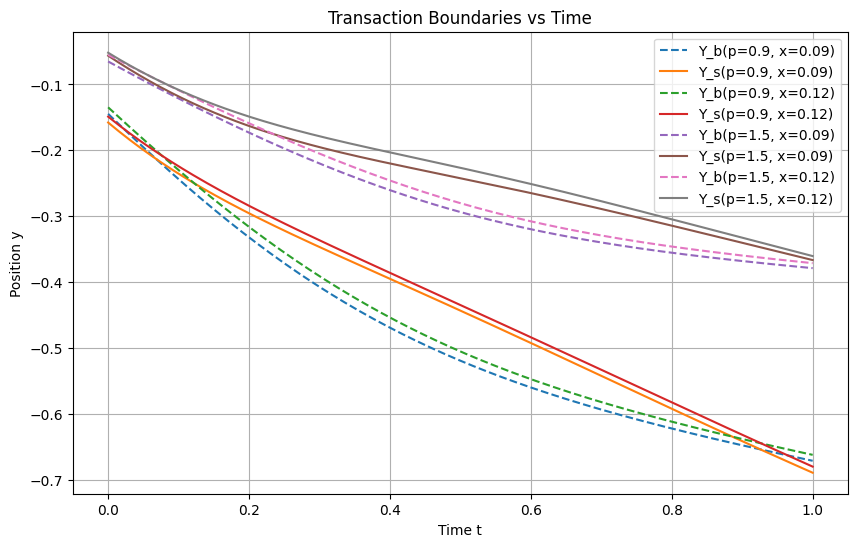

In [18]:
# Fix (p, x) and vary t
t_vec = np.linspace(0, 1.0, 200)
fixed_points = [
    (0.9, 0.09),
    (0.9, 0.12),
    (1.5, 0.09),
    (1.5, 0.12),
]

plt.figure(figsize=(10, 6))
for p_fix, x_fix in fixed_points:
    T = torch.tensor(t_vec, dtype=torch.float64, device=device)
    P = torch.full_like(T, p_fix)
    X = torch.full_like(T, x_fix)
    with torch.no_grad():
        yb = net_yb(T, P, X).cpu().numpy()
        ys = net_ys(T, P, X).cpu().numpy()
    plt.plot(t_vec, yb, '--', label=f'Y_b(p={p_fix}, x={x_fix})')
    plt.plot(t_vec, ys, '-',  label=f'Y_s(p={p_fix}, x={x_fix})')

plt.xlabel('Time t')
plt.ylabel('Position y')
plt.title('Transaction Boundaries vs Time')
plt.legend()
plt.grid(True)
plt.show()

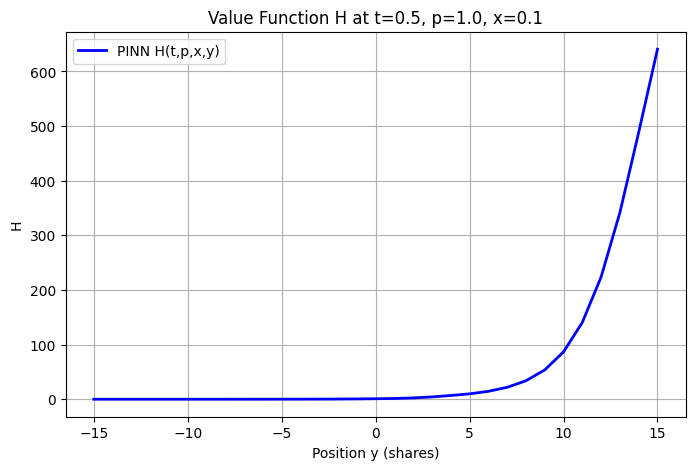

In [19]:
# Example: H vs y at fixed t=0.5, p=1.0, x=0.1
y_vec = np.arange(-15, 16)
t_fix = 0.5
p_fix = 1.0
x_fix = 0.1

T = torch.full((len(y_vec),), t_fix, dtype=torch.float64, device=device)
P = torch.full((len(y_vec),), p_fix, dtype=torch.float64, device=device)
X = torch.full((len(y_vec),), x_fix, dtype=torch.float64, device=device)
Y = torch.tensor(y_vec, dtype=torch.float64, device=device)

with torch.no_grad():
    u = net_u(T, P, X, Y)
    H = torch.exp(u).cpu().numpy()

plt.figure(figsize=(8,5))
plt.plot(y_vec, H, 'b-', linewidth=2, label='PINN H(t,p,x,y)')
plt.xlabel('Position y (shares)')
plt.ylabel('H')
plt.title(f'Value Function H at t={t_fix}, p={p_fix}, x={x_fix}')
plt.legend()
plt.grid(True)
plt.show()

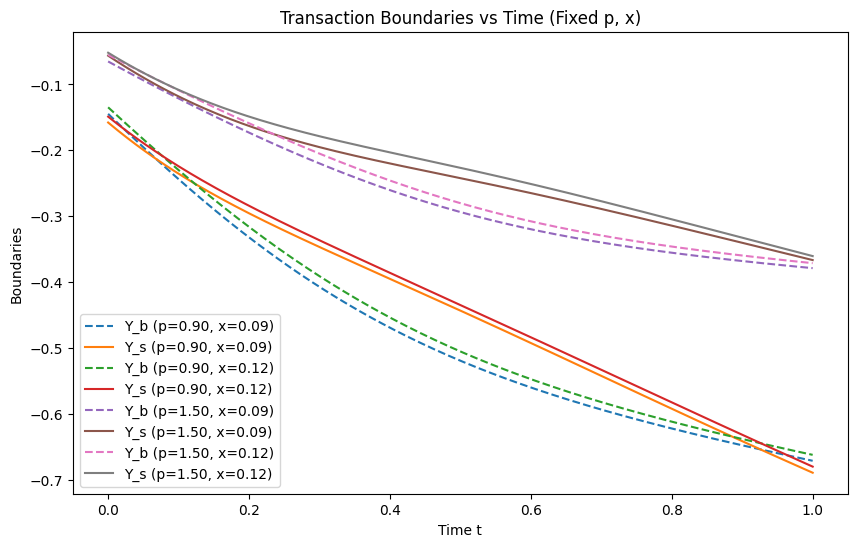

RuntimeError: mat1 and mat2 shapes cannot be multiplied (49x147 and 3x64)

In [20]:
# Boundaries vs time for fixed (p, x) pairs (like paper Fig. 2/3, 4–12)
fixed_points = [(0.9, 0.09), (0.9, 0.12), (1.5, 0.09), (1.5, 0.12)]  # Paper's sensitivity points
t_tensor = torch.tensor(t_vals, dtype=torch.float64, device=device).unsqueeze(1)

plt.figure(figsize=(10, 6))
for p_fix, x_fix in fixed_points:
    p_tens = torch.full_like(t_tensor, p_fix)
    x_tens = torch.full_like(t_tensor, x_fix)
    yb = net_yb(t_tensor.squeeze(), p_tens.squeeze(), x_tens.squeeze()).cpu().detach().numpy()
    ys = net_ys(t_tensor.squeeze(), p_tens.squeeze(), x_tens.squeeze()).cpu().detach().numpy()
    plt.plot(t_vals, yb, label=f'Y_b (p={p_fix:.2f}, x={x_fix:.2f})', linestyle='--')
    plt.plot(t_vals, ys, label=f'Y_s (p={p_fix:.2f}, x={x_fix:.2f})')
plt.xlabel('Time t')
plt.ylabel('Boundaries')
plt.title('Transaction Boundaries vs Time (Fixed p, x)')
plt.legend()
plt.show()

# Surface plot over (p, x) at fixed t=0.5 (like paper Fig. 1)
p_mesh, x_mesh = np.meshgrid(p_vals[1:-1], x_vals[1:-1])  # Avoid edges
t_fix = torch.full(p_mesh.shape, 0.5, device=device)
p_tens = torch.tensor(p_mesh, dtype=torch.float64, device=device)
x_tens = torch.tensor(x_mesh, dtype=torch.float64, device=device)
yb_surf = net_yb(t_fix, p_tens, x_tens).cpu().detach().numpy()
ys_surf = net_ys(t_fix, p_tens, x_tens).cpu().detach().numpy()

fig = plt.figure(figsize=(12, 5))
ax1 = fig.add_subplot(121, projection='3d')
ax1.plot_surface(p_mesh, x_mesh, yb_surf, cmap='viridis')
ax1.set_xlabel('Price p'); ax1.set_ylabel('Spread x'); ax1.set_zlabel('Y_b')
ax1.set_title('Buy Boundary at t=0.5')

ax2 = fig.add_subplot(122, projection='3d')
ax2.plot_surface(p_mesh, x_mesh, ys_surf, cmap='plasma')
ax2.set_xlabel('Price p'); ax2.set_ylabel('Spread x'); ax2.set_zlabel('Y_s')
ax2.set_title('Sell Boundary at t=0.5')
plt.show()